In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import corner


events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [6]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
        try:
            posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")

            quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]
        except:
            continue

    return quantiles

quantiles = quantile_list("log10_mej_dyn")

Text(0.5, 0, 'chirp mass quantiles')

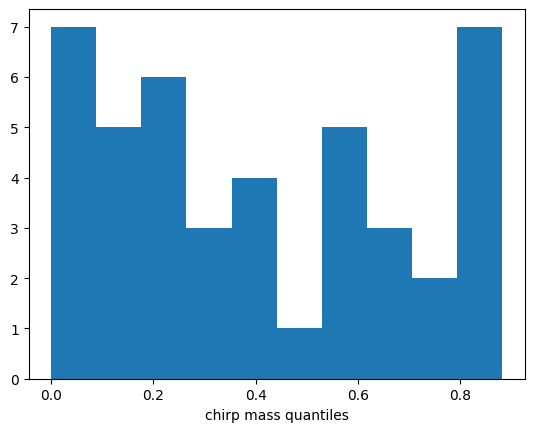

In [7]:

plt.hist(quantiles)
plt.xlabel("chirp mass quantiles")

In [8]:
inds = quantiles.argsort()
print(inds)

[ 2 17 31 32 10 27 30  9 37  5  0  7 35 13 16 22 41 28 39 18  3 33 23  4
  1 42 21 19 38  6 24 20 26  8 14 40 29 11 12 15 34 36 25]


In [11]:
quantiles_mass_ratio

array([0.        , 0.        , 0.        , 0.03829101, 0.95646289,
       0.46367347, 0.78897573, 0.63950672, 0.58148571, 0.06378803,
       0.88081617, 0.32045053, 0.5258923 , 0.12721755, 0.98222029,
       0.17039163, 0.60498138, 0.55898689, 0.79796163, 0.68098444,
       0.69137098, 0.95064019, 0.76118842, 0.8972722 , 0.47047244,
       0.50456781, 0.777956  , 0.02713851, 0.69865818, 0.47647849,
       0.35205733, 0.3365897 , 0.61488737, 0.15439932, 0.8544862 ,
       0.52871135, 0.53313953, 0.03837369, 0.75428034, 0.        ,
       0.846084  , 0.        , 0.87136465])

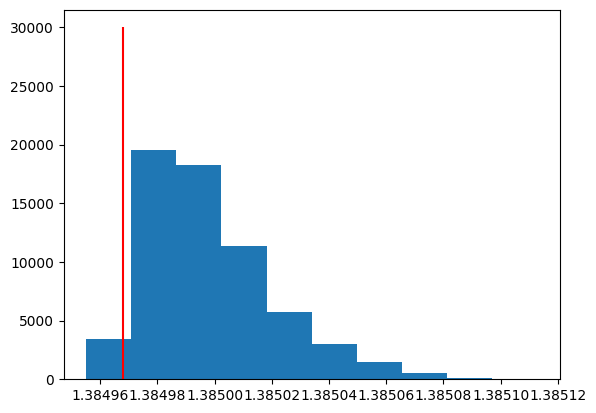

In [7]:
posterior = np.load("./gw_posteriors/source_42/posterior.npz")
plt.hist(posterior["chirp_mass"], density=True)
plt.vlines([events.loc[42, "chirp_mass"]], 0, 30_000, color="red")

In [19]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [23]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


In [31]:
import jax

jax.random.uniform(jax.random.key(57191), shape=(10,), minval=1.32, maxval=1.2)

Array([1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32],      dtype=float64)

In [2]:
quantiles_iota_gw = np.zeros(events.shape[0])
quantiles_dL_gw = np.zeros(events.shape[0])
quantiles_iota_em = np.zeros(events.shape[0])
quantiles_dL_em = np.zeros(events.shape[0])


for j in range(events.shape[0]):

    gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
    gw_posterior = dict(np.load(gw_file, allow_pickle=True))
    quantiles_iota_gw[j] = np.sum(gw_posterior["cos_theta_jn"] <= np.cos(events.loc[j, "theta_jn"])) / gw_posterior["cos_theta_jn"].shape[0]
    quantiles_dL_gw[j] = np.sum(gw_posterior["luminosity_distance"] <= events.loc[j, "luminosity_distance"]) / gw_posterior["luminosity_distance"].shape[0] 
 
    
    em_file = f"./em_posteriors/source_{j}/posterior.npz"
    em_posterior = dict(np.load(em_file, allow_pickle=True))
    upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))
    quantiles_iota_em[j] = np.sum(em_posterior["cos_theta_jn"] <= np.cos(events.loc[j, "theta_jn"])) / em_posterior["cos_theta_jn"].shape[0]
    quantiles_dL_em[j] = np.sum(em_posterior["luminosity_distance"] <= events.loc[j, "luminosity_distance"]) / em_posterior["luminosity_distance"].shape[0] 
 

In [6]:
quantiles_dL_em.argsort()

array([30, 24, 27, 34,  4, 14, 10, 12, 11, 33,  7, 25,  6,  1, 29, 17,  0,
        9, 21, 16, 22, 19, 23, 35, 15, 13, 18, 20,  8, 32, 26,  3,  2, 28,
        5, 31])

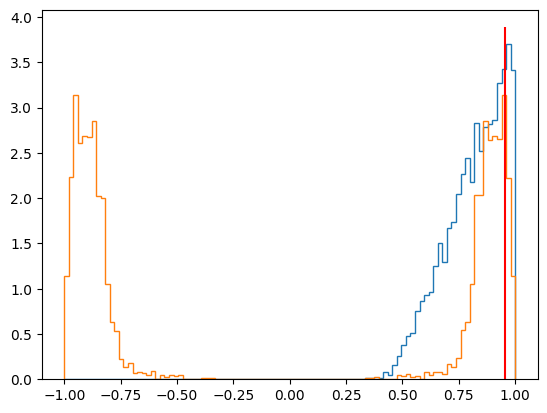

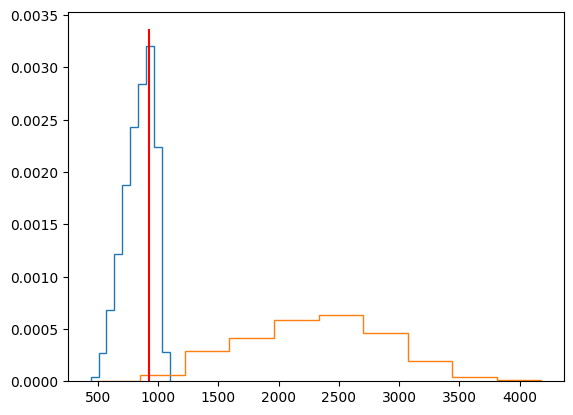

In [16]:
src = 30


gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
gw_posterior = dict(np.load(gw_file, allow_pickle=True))
  
em_file = f"./em_posteriors/source_{j}/posterior.npz"
em_posterior = dict(np.load(em_file, allow_pickle=True))
upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))

plt.hist(gw_posterior["cos_theta_jn"], histtype="step", density=True, bins = np.linspace(-1, 1, 100))
plt.hist(em_posterior["cos_theta_jn"], histtype="step", density=True, bins = np.linspace(-1, 1, 100))
plt.vlines([np.cos(events.loc[src, "theta_jn"])], *plt.gca().get_ylim(), color="red")
plt.show()

plt.hist(gw_posterior["luminosity_distance"], histtype="step", density=True)
plt.hist(em_posterior["luminosity_distance"], histtype="step", density=True)
plt.vlines([events.loc[src, "luminosity_distance"]], *plt.gca().get_ylim(), color="red")
plt.show()

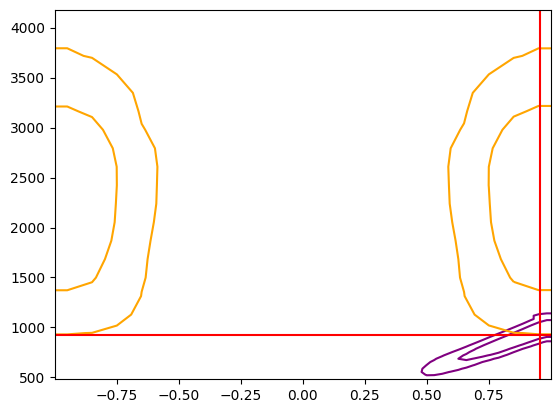

In [27]:

corner.hist2d(gw_posterior["cos_theta_jn"], 
              gw_posterior["luminosity_distance"], 
              color="purple",
              plot_density=False,
              levels=[0.68, 0.95],
              smooth=True,
              plot_datapoints=False)

corner.hist2d(em_posterior["cos_theta_jn"], 
              em_posterior["luminosity_distance"], 
              color="orange",
              plot_density=False,
              levels=[0.68, 0.95],
              smooth=True,
              plot_datapoints=False)

plt.hlines([events.loc[src, "luminosity_distance"]], *plt.gca().get_xlim(), color="red")
plt.vlines([np.cos(events.loc[src, "theta_jn"])], *plt.gca().get_ylim(), color="red")

In [29]:
events.loc[30]

Unnamed: 0                              30
redshift                           0.18428
luminosity_distance             924.403065
mass_1_source                     1.290723
mass_2_source                     1.113477
chi_eff                          -0.037103
chi_1                            -0.049356
chi_2                              -0.0229
mass_1                            1.528577
mass_2                            1.318669
radius_1                         12.182818
radius_2                         12.197589
lambda_1                        627.442453
lambda_2                       1453.390536
theta_jn                          0.294511
phase                             1.539654
psi                               1.067298
ra                                4.178841
dec                                0.64343
geocent_time             2227325820.022273
prompt_collapse                          4
inclination_EM                    0.294511
log10_mej_dyn                    -2.387698
v_ej_dyn   

In [30]:
np.cos(events.loc[30, 'theta_jn'])

np.float64(0.9569442024737618)